# Create population data figure

## Imports

In [1]:
from pathlib import Path
import re
import logging

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, Normalize
from matplotlib.cm import ScalarMappable

from gulp2p.preproc.tiff import Tiff
from gulp2p.preproc.experiment import Experiment, create_expt_df
from gulp2p.preproc import utils, imaging, behavior, trial as tr
from gulp2p.analysis import head_direction as hd
from gulp2p.viz import plotting

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = "none"

### Logging config

In [2]:
log_level = logging.INFO    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)

#### Outline:
- Select trials
  - Organize trials into expts
- Get mean bump profile
- Fit cosine to bump
- calculate r^2
- generate population plot with r^2

## Select Data

### Functions:

In [3]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

### Create trial dataframe:

In [4]:
TIFF_FOLDER = Path(r"Z:\2PImaging\Kerstin\MIMS")

trial_df = tr.create_trial_df(TIFF_FOLDER, CELL_TYPES, GENETIC_TOOLS)

In [5]:
trial_df.head()

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1


### Sort into experiments:

In [6]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

2024-09-16 13:35:25,664 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00001.tif
2024-09-16 13:35:25,673 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00002.tif
2024-09-16 13:35:25,683 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00003.tif
2024-09-16 13:35:25,690 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00004.tif
2024-09-16 13:35:25,698 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_Stripe_00001.tif
2024-09-16 13:35:25,705 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not pr

In [7]:
expt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   expt_name         40 non-null     object
 1   trial_paths       40 non-null     object
 2   date              40 non-null     object
 3   line              39 non-null     object
 4   cell_type         39 non-null     object
 5   genetic_tool      39 non-null     object
 6   fly               40 non-null     int64 
 7   trials            40 non-null     object
 8   proc_trial_count  40 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 2.9+ KB


In [8]:
expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3
39,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5


### Load data

In [9]:
# Select only experiments that include processed trials
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]

In [10]:
# Create Experiment objects
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

2024-09-16 13:35:42,413 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-09-16 13:35:42,419 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-09-16 13:35:42,465 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_7864\3279863305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [11]:
# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

In [12]:
print(f"number of processed experiments: {len(processed_expt_df)}")
processed_expt_df.head()

number of processed experiments: 23


,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt
10,20231206_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231206\20231206_D...,20231206,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,10,<gulp2p.preproc.experiment.Experiment object a...
12,20231207_DR019xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,9,<gulp2p.preproc.experiment.Experiment object a...
13,20231207_DR019xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...
14,20231212_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,11,<gulp2p.preproc.experiment.Experiment object a...
15,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...


## Create Figures:

### Plot bump profile for each experiment

In [13]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [14]:
for index, expt_df_row in processed_expt_df.iterrows():
    # Plot experiment
    expt = expt_df_row['expt']

    print(expt_df_row['expt_name'])
    fig, axd = plotting.plot_expt(expt)

    fig_title = expt_df_row['expt_name']
    fig.suptitle(fig_title)
    for fmt in PLOT_FORMATS:
        fig.savefig(Path(OUTPUT_FOLDER, fig_title + fmt), dpi=600)
    plt.close(fig)

2024-09-16 13:35:42,668 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2206 nans / 2611 total elements
2024-09-16 13:35:42,675 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2461 nans / 2613 total elements
2024-09-16 13:35:42,683 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2382 nans / 2612 total elements
2024-09-16 13:35:42,689 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2382 nans / 2611 total elements
2024-09-16 13:35:42,696 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2395 nans / 2612 total elements
2024-09-16 13:35:42,703 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_h

20231206_DR018xiGluSnFr_Fly1


2024-09-16 13:35:42,717 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2398 nans / 2612 total elements
2024-09-16 13:35:42,724 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2366 nans / 2477 total elements
2024-09-16 13:35:42,731 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2447 nans / 2612 total elements
2024-09-16 13:35:42,737 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2206 nans / 2611 total elements
2024-09-16 13:35:42,744 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2461 nans / 2613 total elements
2024-09-16 13:35:42,751 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_h

20231207_DR019xiGluSnFr_Fly1


2024-09-16 13:35:46,894 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 13887 nans / 20895 total elements
2024-09-16 13:35:50,714 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1879 nans / 2322 total elements
2024-09-16 13:35:50,719 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 256 nans / 285 total elements
2024-09-16 13:35:50,725 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2098 nans / 2323 total elements
2024-09-16 13:35:50,731 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1879 nans / 2322 total elements
2024-09-16 13:35:50,735 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_h

...

20240702_DR015xiGluSnfR_Fly1


2024-09-16 13:36:45,327 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 834 nans / 2621 total elements
2024-09-16 13:36:45,334 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1156 nans / 2621 total elements
2024-09-16 13:36:45,340 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1052 nans / 2621 total elements
2024-09-16 13:36:45,345 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 993 nans / 2621 total elements
2024-09-16 13:36:45,351 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 890 nans / 2621 total elements
2024-09-16 13:36:45,357 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head

20240708_DR015xiGluSnfR_Fly1


2024-09-16 13:36:58,884 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2698 nans / 2983 total elements
2024-09-16 13:36:58,891 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2833 nans / 2985 total elements
2024-09-16 13:36:58,898 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2624 nans / 2985 total elements
2024-09-16 13:36:58,913 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1967 nans / 2983 total elements
2024-09-16 13:36:58,933 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2494 nans / 2986 total elements
2024-09-16 13:36:58,942 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_h

20240708_DR015xiGluSnfR_Fly2


### Plot population data:

In [15]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

2024-09-16 13:37:02,087 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-09-16 13:37:02,093 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-09-16 13:37:02,130 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_7864\2055239172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [16]:
type(expt.upper_deltaf)

numpy.ndarray

In [17]:
stat_df_dicts = []
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']
    data_point = {"expt_name": expt_df_row['expt_name']}
    for bump_region in ['upper', 'lower', 'mean']:
        # HD offset variance
        hd_offset = hd.get_hd_offset(expt, mode=bump_region)
        circ_var = hd.get_circ_var(hd_offset)
        data_point[f"{bump_region}_bump_hd_offset_circ_var"] = circ_var

        # Cosine fit
        if bump_region == 'upper':
            aligned_bumps = hd.align_bumps(expt.upper_deltaf, min_r=0.15, offset=3)
        if bump_region == 'lower':
            aligned_bumps = hd.align_bumps(expt.lower_deltaf, min_r=0.15, offset=3)
        if bump_region == 'mean':
            upper_aligned_bump = hd.align_bumps(expt.upper_deltaf, min_r=0.15, offset=3)
            lower_aligned_bump = hd.align_bumps(expt.lower_deltaf, min_r=0.15, offset=3)
            aligned_bumps = np.mean(np.array([upper_aligned_bump, lower_aligned_bump]), axis=0)

        mean_bump = np.mean(aligned_bumps, axis=0)
        parameters, covariance, r_squared = hd.get_cos_fit(mean_bump, cos_func=hd.standard_cos_func)

        data_point[f"{bump_region}_bump_r2"] = r_squared
        data_point[f"{bump_region}_bump_cosine_params"] = parameters

    stat_df_dicts.append(data_point)
stats_df = pd.DataFrame(stat_df_dicts)

2024-09-16 13:37:02,200 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 18257 nans / 25984 total elements
2024-09-16 13:37:02,411 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 20431 nans / 25984 total elements
2024-09-16 13:37:02,642 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 24041 nans / 25984 total elements
2024-09-16 13:37:03,018 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 10393 nans / 20895 total elements
2024-09-16 13:37:03,184 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 10285 nans / 20895 total elements
2024-09-16 13:37:03,365 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_

In [18]:
processed_expt_df = pd.merge(processed_expt_df, stats_df, on="expt_name")

In [19]:
processed_expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt,upper_bump_hd_offset_circ_var,upper_bump_r2,upper_bump_cosine_params,lower_bump_hd_offset_circ_var,lower_bump_r2,lower_bump_cosine_params,mean_bump_hd_offset_circ_var,mean_bump_r2,mean_bump_cosine_params
18,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2,<gulp2p.preproc.experiment.Experiment object a...,0.867103,0.876071,"[0.24748501318411625, 0.7888167042899707, 3.48...",0.892934,0.851111,"[0.1966820393359532, 0.7853011915210196, 3.451...",0.879330,0.944854,"[0.2220564980648707, 0.7872069547003417, 3.471..."
19,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5,<gulp2p.preproc.experiment.Experiment object a...,0.971288,0.990188,"[0.0748518491852543, 0.7862650517048012, 3.517...",0.922484,0.990222,"[0.07767088734934015, 0.7862770492694201, 3.51...",0.924327,0.990846,"[0.0762612745869357, 0.7862702864633287, 3.514..."
20,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14,<gulp2p.preproc.experiment.Experiment object a...,0.759164,0.953619,"[0.16654483089293287, 0.7872394004880564, 3.52...",0.689395,0.983357,"[0.1696915272088644, 0.7864439004833012, 3.517...",0.768669,0.970906,"[0.1681170261426006, 0.7868363122169872, 3.521..."
21,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...,0.910924,0.981554,"[0.04486467935915117, 0.7862473057556638, 3.51...",0.962037,0.831594,"[0.084872052584615, 0.7854719198868724, 3.5031...",0.957103,0.933678,"[0.06486822460873722, 0.7857338261193225, 3.50..."
22,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5,<gulp2p.preproc.experiment.Experiment object a...,0.509999,0.946604,"[0.08025676933076505, 0.7876711824697922, 3.53...",0.844462,0.931983,"[0.05497957527481066, 0.7874503982126017, 3.54...",0.856616,0.945443,"[0.0676176167545131, 0.7875749076283604, 3.539..."


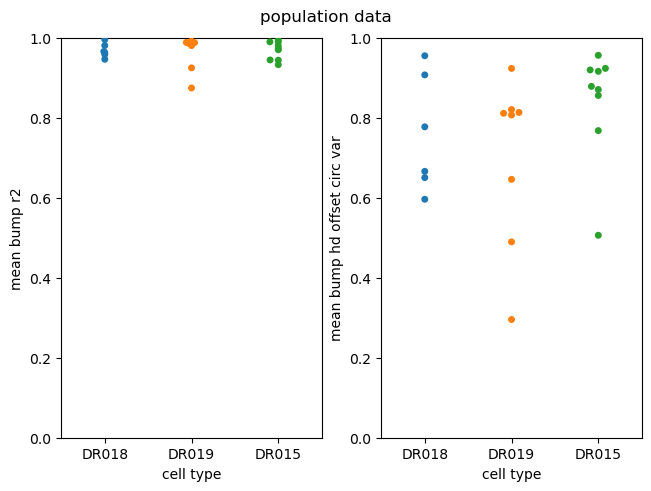

In [20]:
import seaborn as sns

category = 'cell_type'
stats = ['mean_bump_r2', 'mean_bump_hd_offset_circ_var']

fig, ax = plt.subplots(1, 2,
                       layout='constrained')
for index, stat in enumerate(stats):

    sns.swarmplot(data=processed_expt_df, x=category, y=stat,
                  ax=ax[index])
    ax[index].set_ylim([0,1])
    ax[index].set_xlabel(" ".join(category.split('_')))
    ax[index].set_ylabel(" ".join(stat.split('_')))

fig.suptitle("population data")

# Save plot
for fmt in PLOT_FORMATS:
    fig.savefig(Path(OUTPUT_FOLDER, "population_data" + fmt), dpi=600)

# Save raw stats
processed_expt_df.to_csv(Path(OUTPUT_FOLDER, "population_data.csv"))

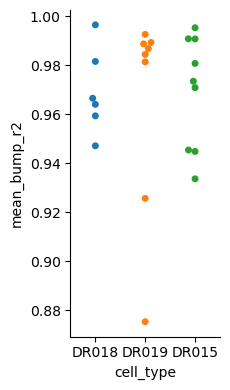

In [21]:
g = sns.catplot(
    data=processed_expt_df, x="cell_type", y='mean_bump_r2',
    kind="swarm", height=4, aspect=.6,
)


### Plot Each trial individually

In [22]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile\individual_trials")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [23]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

In [24]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

2024-09-16 13:37:13,590 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-09-16 13:37:13,595 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-09-16 13:37:13,632 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_7864\2055239172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [25]:
# Plot Individual trials
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    output_dir = Path(OUTPUT_FOLDER, expt_df_row['expt_name'])
    output_dir.mkdir(exist_ok=True, parents=True)

    for trial in expt.trials:
        trial_expt = Experiment(trials=[trial])
        logger.info(f"Plotting trial {trial_expt.trials[0].name}")
        try:
            fig, axd = plotting.plot_expt(trial_expt)
        except:
            continue
        trial_metadata = tr.parse_trial_name(trial.path, CELL_TYPES, GENETIC_TOOLS)
        fig_title = f"{trial_metadata['date']}_{trial_metadata['line']}_Fly{trial_metadata['fly']}_Trial{trial_metadata['trial']}"
        # print(fig_title)
        fig.suptitle(fig_title)
        for fmt in PLOT_FORMATS:
            fig.savefig(Path(output_dir, fig_title + fmt), dpi=600)
        plt.close(fig)


2024-09-16 13:37:13,678 - INFO - __main__ - [3148647589.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00001
2024-09-16 13:37:13,747 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2206 nans / 2611 total elements
2024-09-16 13:37:13,753 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2206 nans / 2611 total elements
2024-09-16 13:37:13,762 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1595 nans / 2611 total elements
2024-09-16 13:37:13,765 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2032 nans / 2611 total elements
2024-09-16 13:37:13,769 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2206 n

In [26]:
## Plot PB with ROI's
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    output_dir = Path(OUTPUT_FOLDER, expt_df_row['expt_name'])
    output_dir.mkdir(exist_ok=True, parents=True)

    for trial in expt.trials:
        fig, ax = plt.subplots(figsize=(5,10), layout="constrained")
        plotting.plot_roi(expt.trials[0], ax)
        ax.set_title("")
        trial_metadata = tr.parse_trial_name(trial.path, CELL_TYPES, GENETIC_TOOLS)
        fig_title = f"{trial_metadata['date']}_{trial_metadata['line']}_Fly{trial_metadata['fly']}_Trial{trial_metadata['trial']}_PB_with_rois"
        for fmt in PLOT_FORMATS:
            fig.savefig(Path(output_dir, fig_title + fmt), dpi=600)
        plt.close(fig)

In [27]:
expt_df[expt_df['cell_type'] == 'DR015']

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
16,20231214_DR015xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231214\20231214_D...,20231214,DR015xiGluSnFr,DR015,iGluSnFR,1,[],0
17,20231214_DR015xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231214\20231214_D...,20231214,DR015xiGluSnFr,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
22,20240118_DR015xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240118\20240118_D...,20240118,DR015xiGluSnFr,DR015,iGluSnFR,1,[],0
23,20240118_DR015xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240118\20240118_D...,20240118,DR015xiGluSnFr,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
33,20240618_DR015xiGluSNfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240618\20240618_D...,20240618,DR015xiGluSNfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,7
34,20240620_DRo15xiGluSnFR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240620\20240620_D...,20240620,DRo15xiGluSnFR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,8
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3


### Examine 20240125_DR019xiGluSnFR_Fly02_00005 more closely

In [28]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [29]:
# tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00001.tif")
root_tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS\20231212")

In [30]:
trial_df = tr.create_trial_df(root_tiff_folder, CELL_TYPES, GENETIC_TOOLS)

In [31]:
trial_df

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,5
5,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,6
6,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,7
7,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,8
8,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,9
9,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,10


In [32]:
trial_df = trial_df[(trial_df['fly']==2) & (trial_df['trial']==3)]

In [33]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

In [34]:
expt_df

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
0,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,1


In [35]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

In [36]:
# def filter_mean_rois(mean_rois, circ_rs, min_r=0.15):
#     # in place change
#     if np.issubdtype(mean_rois.dtype, np.integer):
#         empty_value = -1
#     else:
#         empty_value = np.nan

#     filtered_mean_rois = np.copy(mean_rois)

#     mask = (circ_rs <  min_r)
#     filtered_mean_rois[mask] = empty_value
#     if np.isnan(filtered_mean_rois).all():
#         logger.warning(f"No circular mean found with r >= {min_r}")
#     return filtered_mean_rois



# bump_region = "mean"

# upper_deltaf = np.array(expt.synced_df.iloc[:, expt.rois_per_arm:expt.num_rois])
# lower_deltaf = np.array(expt.synced_df.iloc[:, 0:expt.rois_per_arm])

# if bump_region == "upper":
#     deltaf = upper_deltaf
# if bump_region == "lower":
#     deltaf = lower_deltaf
# if bump_region == "mean":
#     deltaf = np.mean(np.array([upper_deltaf, lower_deltaf]), axis=0)

# mean_rois = plotting.get_mean_rois(deltaf, precise=True)
# circ_rs = plotting.get_circ_rs(deltaf)
# filtered_mean_rois = filter_mean_rois(mean_rois, circ_rs, min_r=0.3)
# # Check if filter_mean_rois filtered out all points
# if np.isnan(filtered_mean_rois).all():
#     min_r = np.quantile(circ_rs, 1-0.1)
#     print(f"refiltering circular means with r >= {min_r}")
#     filtered_mean_rois = filter_mean_rois(mean_rois, circ_rs, min_r=min_r)


# int_head_direction = ((filtered_mean_rois * 360 / 8)) % 360
# ext_head_direction = (expt.synced_df.angle) % 360

# hd_offset = (int_head_direction - ext_head_direction) % 360

# print(f"filtered_mean_rois all nan: {np.isnan(filtered_mean_rois).all()}")
# print(f"int_head_direction all nan: {np.isnan(int_head_direction).all()}")
# print(f"ext_head_direction all nan: {np.isnan(ext_head_direction).all()}")

In [37]:
# imaging.process_all(tiff_paths, save=True, skip=False, use_full_volume=False)

2024-09-16 13:56:53,591 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4195 nans / 4195 total elements
2024-09-16 13:56:53,614 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4195 nans / 4195 total elements
2024-09-16 13:56:53,654 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4176 nans / 4195 total elements
2024-09-16 13:56:53,664 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4193 nans / 4195 total elements
2024-09-16 13:56:53,682 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4195 nans / 4195 total elements
C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\analysis\head_direction.py:123: RuntimeWarning: angle

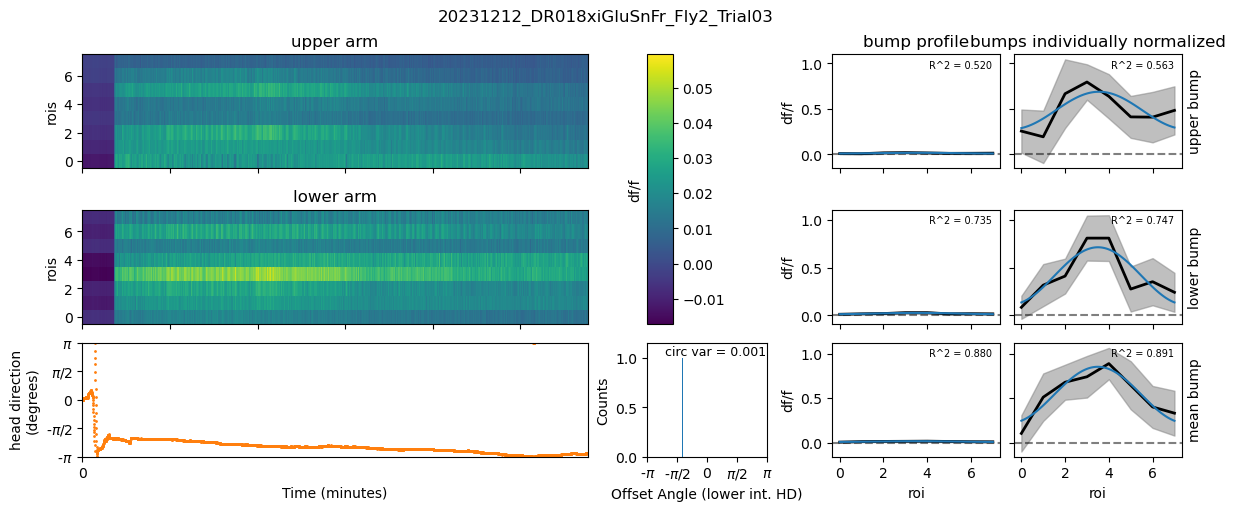

In [38]:

for index, expt_df_row in processed_expt_df.iterrows():
    # Plot experiment
    expt = expt_df_row['expt']

    logger.debug(f"{expt_df_row['expt_name']}")
    # print(expt_df_row['expt_name'])
    fig, axd = plotting.plot_expt(expt)

    fig_title = expt_df_row['expt_name'] + f"_Trial{expt.trials[0].name[-2:]}"
    fig.suptitle(fig_title)
    for fmt in PLOT_FORMATS:
        fig.savefig(Path(OUTPUT_FOLDER, fig_title + fmt), dpi=600)

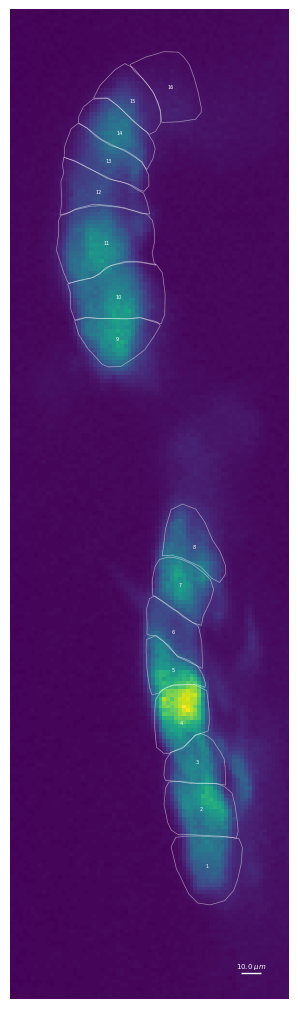

In [39]:
fig, ax = plt.subplots(figsize=(5,10), layout="constrained")
plotting.plot_roi(expt.trials[0], ax)
ax.set_title("")
for fmt in PLOT_FORMATS:
    fig.savefig(Path(OUTPUT_FOLDER, fig_title + "PB_with_rois" + fmt), dpi=600)

In [43]:
# plot offset of ext and int hd
# Plot circ var of offset

upper_deltaf = expt.upper_deltaf
lower_deltaf = expt.lower_deltaf

circ_means = hd.get_circ_mean_rois(upper_deltaf, precise=True)
circ_rs = hd.get_circ_rs(upper_deltaf)
filtered_mean_rois = hd.filter_circ_means(circ_means, circ_rs, min_r=0.3)

int_visual_shift = -120
int_head_direction = ((circ_means * 360 / 8) + int_visual_shift) % 360

In [44]:
ext_visual_shift = 180
ext_head_direction = (expt.synced_df.angle * 1 + ext_visual_shift) % 360

In [45]:
offset_visual_shift = 180
hd_offset =  (int_head_direction - ext_head_direction + offset_visual_shift) % 360

In [46]:
Y_pred = hd_offset
Y_true = np.full(hd_offset.shape, hd_offset.mean())
offset_mse = np.square(np.subtract(Y_true,Y_pred)).mean() 

Text(0.99, 0.95, 'circ R = 0.839')

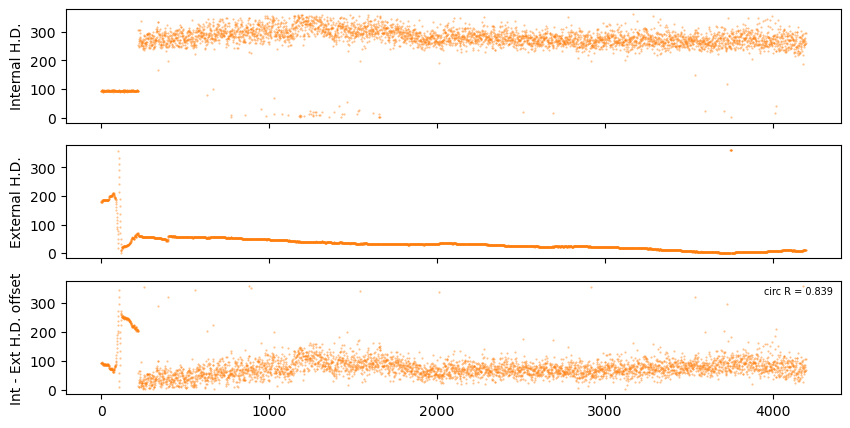

In [47]:
fig, axs = plt.subplots(3, figsize=(10,5), sharex=True)
axs[0].plot(int_head_direction, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[0].set_ylabel("Internal H.D.")
axs[1].plot(ext_head_direction, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[1].set_ylabel("External H.D.")
axs[2].plot(hd_offset, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[2].set_ylabel("Int - Ext H.D. offset")

# axs[0].set_xlim(5000, 10000)

circ_r = pingouin.circ_r(pingouin.convert_angles(hd_offset))
metric = f"circ R = {circ_r:.3f}"
axs[2].text(0.99, 0.95, metric, fontsize=7,
        transform=axs[2].transAxes, ha='right', va='top')